### Getter Insure AI - Insurance Cross-Sell Engine Inside Banking Transactions
##### Bima Kiganjani
By Shawn Irungu

### Project Overview
The Getter Insurance AI is an AI‑powered recommendation engine designed to intelligently identify insurance needs based on a customer’s real‑time banking behavior, financial profile, and life events.
Instead of relying solely on human sales teams or passive marketing, the system embeds insurance recommendations directly into banking channels - such as the mobile app, internet banking, and automated SMS/Email triggers.

### The Problem

Today, bancassurance cross‑selling faces several limitations such as:
1. Low customer engagement - Customers often do not encounter insurance offers unless manually contacted.
2. No contextual relevance - Recommendations are not based on the customer’s actual financial behavior or life events.
3. Limited data-driven insights - Banks rarely leverage transactional patterns to infer insurance needs.
4. Sales team dependency - Cross‑sell performance depends heavily on Sales Team, RM follow-ups and branch visits.

### Project Goal

To build a fully automated, data-driven recommendation system that predicts the right insurance product for the right customer at the right time.

This is achieved using machine learning models trained on:
i) Customer demographics
ii) Income segmentation
iii) Banking transactions
iv) Spending categories
v) Digital engagement
vi) Existing insurance policiesProject Objectives

1. Deliver Personalized, Real-Time Insurance Recommendations by identifying customer life events such as:
i) Salary credit → Life Cover
ii) School fees payment → Education Cover
iii) Travel bookings → Travel Insurance
iv) Electronics purchase → Gadget Insurance
v) Loan disbursements → Credit Life Cover
vi) Vehicle & Fuel Purchase → Motor Insurance
vii) Hospital Bill & Drug Purchase → Medical Insurance. etc

2. Automate Bancassurance Lead Generation
Remove dependence on manual outreach - Auto-generate leads for RMs or trigger self-service digital flows

3. Improve Customer Financial Protection - Ensure customers have adequate protection at key life moments - Reduce underinsurance caused by low awareness

4. Increase Bancassurance Revenue - Drive higher conversion rates by expanding insurance penetration through digital channels

The model then surfaces personalized offers wherever the customer interacts with the bank

### Project Objectives

1. Deliver Personalized, Real-Time Insurance Recommendations by identifying customer life events such as:
i) Salary credit → Life Cover
ii) School fees payment → Education Cover
iii) Travel bookings → Travel Insurance
iv) Electronics purchase → Gadget Insurance
v) Loan disbursements → Credit Life Cover
vi) Vehicle & Fuel Purchase → Motor Insurance
vii) Hospital Bill & Drug Purchase → Medical Insurance. etc

2. Automate Bancassurance Lead Generation
Remove dependence on manual outreach - Auto-generate leads for RMs or trigger self-service digital flows

3. Improve Customer Financial Protection - Ensure customers have adequate protection at key life moments - Reduce underinsurance caused by low awareness

4. Increase Bancassurance Revenue - Drive higher conversion rates by expanding insurance penetration through digital channels


#### _Import Libraries_

In [5]:
# Import Libraries
# data manipulation
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing & feature engineering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 

#classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import shap

#Miscellaneous
import joblib

# Warnings
import warnings
warnings.filterwarnings('ignore')


urllib3 (2.2.3) or chardet (3.0.4) doesn't match a supported version!


#### _Load Datasets_

In [6]:
data = pd.read_csv('semi_rule_based_dataset.csv')

In [7]:
def dataframe_summary(df, name="Dataset"):
    """
    Print a comprehensive summary of a pandas DataFrame including:
    - Basic information
    - Descriptive statistics
    - Missing values analysis
    - Data types distribution
    
    
    
    Parameters:
    - df (pd.DataFrame): The DataFrame to analyze
    - name (str): Optional name for the dataset (for display purposes)
    """
    
    # Create a separator line for better readability
    separator = "=" * 70
    
    print(f"\n{separator}")
    print(f" COMPREHENSIVE SUMMARY FOR: {name.upper()}")
    print(f"{separator}\n")
    
    # 1. Basic Information Section
    print(" BASIC INFORMATION")
    print(f"- Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"- Total Cells: {df.size:,}")
    print(f"- Duplicate Rows: {df.duplicated().sum():,} ({df.duplicated().mean():.1%})")
    print("\n")
    
    # 2. Data Types Overview
    print(" DATA TYPES DISTRIBUTION")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"- {dtype}: {count} columns")
    print("\n")
    
    # 3. Descriptive Statistics
    print(" DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)")
    print(df.describe(include=[np.number]).transpose())
    print("\n")
    
    # 4. Categorical Data Summary
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print(" CATEGORICAL DATA SUMMARY")
        for col in categorical_cols:
            print(f"\nColumn: {col}")
            print(f"- Unique values: {df[col].nunique()}")
            print(f"- Top value: {df[col].mode().values[0]} (count: {df[col].value_counts().max()})")
    print("\n")
    
    # Information
    print(" INFORMATION")
    print(df.info())
    print("\n")

    # 5. Missing Values Analysis
    print(" MISSING VALUES ANALYSIS")
    missing_values = df.isnull().sum()
    missing_percent = (missing_values / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing Values': missing_values,
        'Percentage (%)': missing_percent
    }).sort_values('Percentage (%)', ascending=False)
    
    # Only show columns with missing valuesdef dataframe_summary(df, name="Dataset"):
    """
    Print a comprehensive summary of a pandas DataFrame including:
    - Basic information
    - Descriptive statistics
    - Missing values analysis
    - Data types distribution
    
    
    
    Parameters:
    - df (pd.DataFrame): The DataFrame to analyze
    - name (str): Optional name for the dataset (for display purposes)
    """
    
    # Create a separator line for better readability
    separator = "=" * 70
    
    print(f"\n{separator}")
    print(f" COMPREHENSIVE SUMMARY FOR: {name.upper()}")
    print(f"{separator}\n")
    
    # 1. Basic Information Section
    print(" BASIC INFORMATION")
    print(f"- Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"- Total Cells: {df.size:,}")
    print(f"- Duplicate Rows: {df.duplicated().sum():,} ({df.duplicated().mean():.1%})")
    print("\n")
    
    # 2. Data Types Overview
    print(" DATA TYPES DISTRIBUTION")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"- {dtype}: {count} columns")
    print("\n")
    
    # 3. Descriptive Statistics
    print(" DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)")
    print(df.describe(include=[np.number]).transpose())
    print("\n")
    
    # 4. Categorical Data Summary
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print(" CATEGORICAL DATA SUMMARY")
        for col in categorical_cols:
            print(f"\nColumn: {col}")
            print(f"- Unique values: {df[col].nunique()}")
            print(f"- Top value: {df[col].mode().values[0]} (count: {df[col].value_counts().max()})")
    print("\n")
    
    # Information
    print(" INFORMATION")
    print(df.info())
    print("\n")

    # 5. Missing Values Analysis
    print(" MISSING VALUES ANALYSIS")
    missing_values = df.isnull().sum()
    missing_percent = (missing_values / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing Values': missing_values,
        'Percentage (%)': missing_percent
    }).sort_values('Percentage (%)', ascending=False)
    
    # Only show columns with missing values
    missing_df = missing_df[missing_df['Missing Values'] > 0]
    
    if len(missing_df) > 0:
        print(missing_df)
        print(f"\nTotal missing values: {missing_values.sum():,}")
        print(f"Percentage of total data: {missing_percent.sum()/df.size:.2%}")
    else:
        print("No missing values found in the dataset!")
    print("\n")
    missing_df = missing_df[missing_df['Missing Values'] > 0]
    
    if len(missing_df) > 0:
        print(missing_df)
        print(f"\nTotal missing values: {missing_values.sum():,}")
        print(f"Percentage of total data: {missing_percent.sum()/df.size:.2%}")
    else:
        print("No missing values found in the dataset!")
    print("\n")

#### _customers summary_

In [8]:
dataframe_summary(data, "customers Dataset")


 COMPREHENSIVE SUMMARY FOR: CUSTOMERS DATASET

 BASIC INFORMATION
- Shape: 35000 rows, 12 columns
- Total Cells: 420,000
- Duplicate Rows: 0 (0.0%)


 DATA TYPES DISTRIBUTION
- object: 8 columns
- int64: 4 columns


 DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)
                  count           mean           std    min       25%  \
customer_id     35000.0   17500.500000  10103.774047    1.0   8750.75   
age             35000.0      48.505714     17.900750   18.0     33.00   
amount          35000.0  149921.656371  86620.303356  101.0  74603.00   
premium_amount  35000.0    7782.149000   4189.820508  500.0   4160.00   

                     50%        75%       max  
customer_id      17500.5   26250.25   35000.0  
age                 48.0      64.00      79.0  
amount          149772.0  225299.25  299981.0  
premium_amount    7808.0   11397.00   14999.0  


 CATEGORICAL DATA SUMMARY

Column: income_band
- Unique values: 3
- Top value: High (count: 11706)

Column: customer_segment
- Uniq

In [9]:
data.head()

,customer_id,age,income_band,customer_segment,occupation,city,kyc_risk_rating,amount,category,channel,premium_amount,product_type
0,1,56,High,SME,Community arts worker,Kisumu,High,64878,Groceries,Branch,11058,Medical
1,2,69,High,SME,"Education officer, environmental",Mombasa,High,86117,School Fees,USSD,11046,Life
2,3,46,Low,SME,Insurance underwriter,Nyeri,Low,270564,Travel,App,663,Travel
3,4,32,Medium,Affluent,Investment analyst,Naivasha,Low,26054,Travel,Internet Banking,10351,Travel
4,5,60,High,SME,Tax inspector,Nakuru,Low,270306,Electronics,App,5101,Gadget


In [10]:
print('Number of unique Values')
for col in data.columns:
    print(f"{col}: {data[col].nunique()}")

Number of unique Values
customer_id: 35000
age: 62
income_band: 3
customer_segment: 3
occupation: 639
city: 10
kyc_risk_rating: 3
amount: 33082
category: 5
channel: 4
premium_amount: 13178
product_type: 6


### Split Data & Cleaning Target

In [11]:
X=data.drop(columns=['product_type'])
y=data['product_type']


In [12]:
# confirm no missing values in label
y.value_counts()

Travel       7376
Education    7224
Gadget       7152
Medical      6022
Life         4000
Motor        3226
Name: product_type, dtype: int64

### Clean Predictors (X train, X test)
1. fix missing values
2. normalize text columns
3. fix numeric columns
4. convert date time
5. remove duplicates
6. handle outliers

In [13]:
## Clean Categorical Predictors
# clean them with lowercase, title , strip convert blanks to NaN
cat_cols = ['income_band', 'customer_segment', 'occupation', 'city', 
            'kyc_risk_rating', 'category', 'channel']

for col in cat_cols:
    X[col] = X[col].astype(str).str.strip()
    X[col] = X[col].replace([ "", "nan", "None", " "], np.nan)
    X[col] = X[col].str.title()
    

In [14]:
# clean numeric predictors
# convert all numeric safely
# fill missing numerics with median

num_cols = ['age', 'amount','premium_amount']

for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    X[col] = X[col].fillna(X[col].median())

In [15]:
# Clan Date Columns

#date_cols = ['transaction_date', 'start_date', 'end_date']

#for col in date_cols:
  #  X[col] = pd.to_datetime(X[col], errors='coerce')
   # X[col] = X[col].fillna(X[col].mean())
    

In [16]:
# Create date based features
#for col in date_cols:
   # X[col + '_year'] = X[col].dt.year
  #  X[col + '_month'] = X[col].dt.month
  #  X[col + '_day'] = X[col].dt.day
   # X[col + '_weekday'] = X[col].dt.weekday
    

In [17]:
# Remove Duplicates
X=X.drop_duplicates()


In [18]:
# Verify Cleaning Results

dataframe_summary( X, "Predictors")

# this tells we still have some missing values in the predictors, we can handle them with imputation or drop 
# them depending on the percentage of missingness and importance of the feature.



 COMPREHENSIVE SUMMARY FOR: PREDICTORS

 BASIC INFORMATION
- Shape: 35000 rows, 11 columns
- Total Cells: 385,000
- Duplicate Rows: 0 (0.0%)


 DATA TYPES DISTRIBUTION
- object: 7 columns
- int64: 4 columns


 DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)
                  count           mean           std    min       25%  \
customer_id     35000.0   17500.500000  10103.774047    1.0   8750.75   
age             35000.0      48.505714     17.900750   18.0     33.00   
amount          35000.0  149921.656371  86620.303356  101.0  74603.00   
premium_amount  35000.0    7782.149000   4189.820508  500.0   4160.00   

                     50%        75%       max  
customer_id      17500.5   26250.25   35000.0  
age                 48.0      64.00      79.0  
amount          149772.0  225299.25  299981.0  
premium_amount    7808.0   11397.00   14999.0  


 CATEGORICAL DATA SUMMARY

Column: income_band
- Unique values: 3
- Top value: High (count: 11706)

Column: customer_segment
- Unique valu

In [19]:
X['income_band'].value_counts()

High      11706
Low       11654
Medium    11640
Name: income_band, dtype: int64

In [20]:
X['income_band'].isna().sum()

0

In [21]:
# Dealing with missing values in categorical features

observed = X['income_band'].value_counts(normalize=True)
X['income_band'] = X['income_band'].fillna(
    pd.Series(np.random.choice(observed.index, size=X['income_band'].isna().sum(), p=observed.values))
)

X['income_band']= X['income_band'].fillna('Vary')
X['customer_segment']= X['customer_segment'].fillna('Gold')
X['occupation']= X['occupation'].fillna('Labourer')
X['city']= X['city'].fillna('Thika Road')
X['kyc_risk_rating']= X['kyc_risk_rating'].fillna('Low')
X['category']= X['category'].fillna('Personal')
X['channel']= X['channel'].fillna('App')


In [22]:
mapping = {'Mass': 'Go Banking', 'Affluent': 'Platinum', 'Sme': 'SME'}
X['customer_segment']= X['customer_segment'].replace(mapping)


In [23]:
cleaned = pd.concat([X, y], axis=1)

#cleaned.to_csv('data_cleaned.csv', index=False)


### _VISUALIZATION_

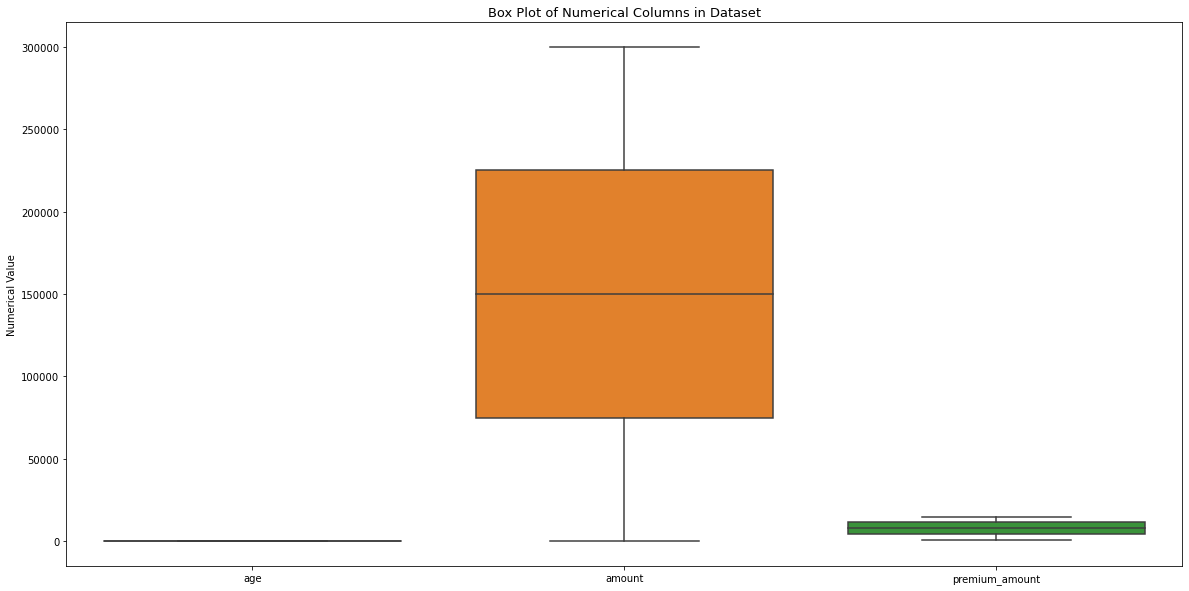

In [24]:
# Plotting box plots of numerical columns - num_cols
plt.figure(figsize=(20, 10))
sns.boxplot(data=[X[col] for col in num_cols])
plt.title("Box Plot of Numerical Columns in Dataset", fontsize=13)
plt.ylabel("Numerical Value")
plt.xticks(range(0,3), num_cols)
plt.show()

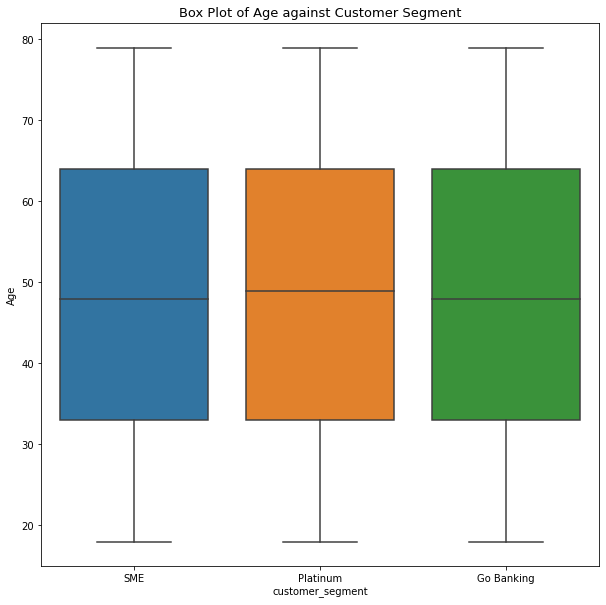

In [25]:
# for AGe
plt.figure(figsize=(10, 10))
sns.boxplot(x='customer_segment', y = 'age', data=X)
plt.title("Box Plot of Age against Customer Segment", fontsize=13)
plt.ylabel("Age")
plt.xticks(range(0,len(X['customer_segment'].unique())), X['customer_segment'].unique())
plt.show()

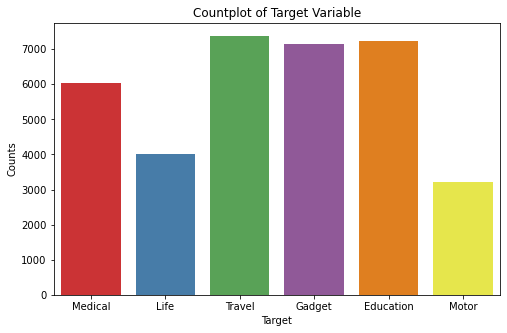

In [26]:
# Plot distribution of target variable.
fig, ax = plt.subplots(figsize=(8,5))
sns.countplot(y, palette='Set1', ax=ax)
y_labels = y.unique()

# Add labels
plt.title('Countplot of Target Variable')
plt.xlabel('Target')
#ax.set_xticklabels(x_labels, fontsize=10)
plt.ylabel('Counts')
plt.show()

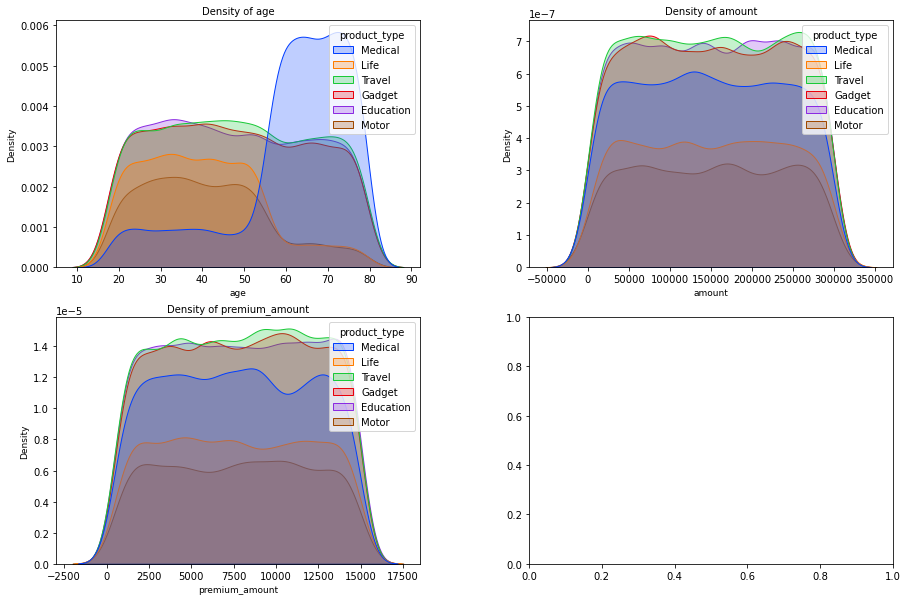

In [27]:
# Set up the subplots with 2 columns and increased spacing
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.subplots_adjust(hspace=0.2, wspace=0.3)  # Increase hspace and wspace

# Create count bar plots for continuous variables

for i, column in enumerate(num_cols):
    row, col = i // 2, i % 2
    sns.kdeplot(data=X, x=column, hue=y, palette='bright', 
                fill=True, ax=axes[row, col])
    axes[row, col].set_title(f'Density of {column}', fontsize=10)
    axes[row, col].set_xlabel(column, fontsize=9)
    axes[row, col].set_ylabel('Density', fontsize=9)
    
plt.savefig('images/density_of_target_class_vs_numerical_features.jpg')
plt.show()

This indicates a nearly normal distribution.

Our data has few features

#### Split Into Train Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### _Preprocessing & Modelling_

In [29]:
# X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

#### Model Evaluation Function

In [30]:
def model_score(model, y_true, y_pred, y_train, y_pred_train):
        # Print classification report, accuracy, precision, recall, f1_score 
        separator = "=" * 70

        print(f"\n{separator}")
        print('MODEL REPORT')
        print(f'{separator}')
        print(classification_report(y_true, y_pred))
        print(f"\n{separator}")

        print('MODEL METRICS - TRAIN SET')
        print(f'{separator}')
        print("Overall accuracy score", accuracy_score(y_train, y_pred_train))
        print("Overall precision score", precision_score(y_train, y_pred_train, average='weighted'))
        print("Overall recall score", recall_score(y_train, y_pred_train, average='weighted'))
        print("Overall F1-score", f1_score(y_train, y_pred_train, average='weighted'))


        print('MODEL METRICS - TEST SET')
        print(f'{separator}')
        print("Overall accuracy score", accuracy_score(y_true, y_pred))
        print("Overall precision score", precision_score(y_true, y_pred, average='weighted'))
        print("Overall recall score", recall_score(y_true, y_pred, average='weighted'))
        print("Overall F1-score", f1_score(y_true, y_pred, average='weighted'))

        #print(f"\n{separator}")
       # print('ROC AUC SCORE')
        #print(f'{separator}')
        #fpr, tpr, thresholds = roc_curve(y_test, y_score_log, multi_class='ovr')
        #print("AUC", auc(fpr, tpr))

        print(f"\n{separator}")
        print('CONFUSION MATRIX')
        print(f'{separator}')

        # Print a confusion matrix    
        cnf_matrix = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix, display_labels=model.classes_)      
        return disp.plot(cmap='Reds')

### Logistic Regression

In [31]:
logreg_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("scaler", StandardScaler(with_mean=False)),  # Logistic needs scaling
        ("classifier", LogisticRegression(
            C=1.0,                    # Regularization strength
            penalty='l2',             # L2 regularization (default)
            solver='lbfgs',           # Fast solver for small datasets
            max_iter=1000,            # Convergence
            random_state=42
        ))
    ]
)

#### _train and predict with Logistic Regression_

In [32]:
# Train and Predict Logistic Model
logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)


MODEL REPORT
              precision    recall  f1-score   support

   Education       0.83      0.79      0.81      1445
      Gadget       0.81      0.80      0.81      1430
        Life       0.63      0.58      0.60       800
     Medical       0.65      0.75      0.70      1205
       Motor       0.52      0.48      0.50       645
      Travel       0.83      0.83      0.83      1475

    accuracy                           0.74      7000
   macro avg       0.71      0.71      0.71      7000
weighted avg       0.74      0.74      0.74      7000


MODEL METRICS - TRAIN SET
Overall accuracy score 0.7555714285714286
Overall precision score 0.7569184239363618
Overall recall score 0.7555714285714286
Overall F1-score 0.7551487637243408
MODEL METRICS - TEST SET
Overall accuracy score 0.742
Overall precision score 0.7429671260074979
Overall recall score 0.742
Overall F1-score 0.7416019334240197

CONFUSION MATRIX


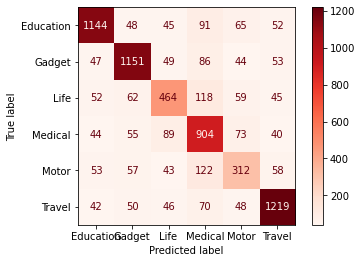

In [33]:
# Logistic Regression Evaluation
model_score(logreg_model, y_test, y_pred_logreg, y_train, logreg_model.predict(X_train))

### Random Forest Model

In [34]:

rf_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=42,
            n_jobs=-1))
            ])

#### _train and predict with random forest_

In [35]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


MODEL REPORT
              precision    recall  f1-score   support

   Education       0.80      0.80      0.80      1445
      Gadget       0.77      0.82      0.79      1430
        Life       0.75      0.62      0.68       800
     Medical       0.72      0.78      0.75      1205
       Motor       0.65      0.50      0.57       645
      Travel       0.79      0.83      0.81      1475

    accuracy                           0.76      7000
   macro avg       0.75      0.73      0.73      7000
weighted avg       0.76      0.76      0.76      7000


MODEL METRICS - TRAIN SET
Overall accuracy score 1.0
Overall precision score 1.0
Overall recall score 1.0
Overall F1-score 1.0
MODEL METRICS - TEST SET
Overall accuracy score 0.7602857142857142
Overall precision score 0.7578622367345943
Overall recall score 0.7602857142857142
Overall F1-score 0.7570653059636103

CONFUSION MATRIX


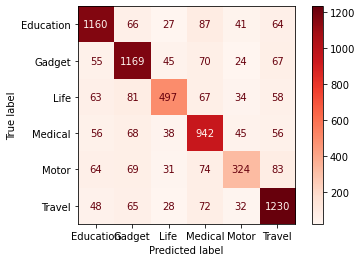

In [36]:
# Evaluate Random Forest Model
model_score(rf_model, y_test, y_pred_rf, y_train, rf_model.predict(X_train))

#### Cross Validation Function

In [37]:
# Create a Function for Cross Validation test
def cross_val_test(K_folds, model_instance, X, y):
    
    # Plot a distribution of train and test accuracies over a range of K folds
    train_accuracy = []
    test_accuracy = []

    for fold in K_folds:
        # Instantiate classifier model
        model = model_instance

        # Perform cross-validation on full dataset to evaluate model performance
        cv_scores = cross_validate(model, X, y, cv=fold, return_train_score=True)

        # Find mean train and test scores
        mean_train_score = np.mean(cv_scores['train_score'])
        mean_test_score = np.mean(cv_scores['test_score'])

        # Append the lists for mean scores
        train_accuracy.append(mean_train_score)
        test_accuracy.append(mean_test_score)

    # Plot the mean train and test scores against K fold
    plt.plot(K_folds, train_accuracy, label='Train score')
    plt.plot(K_folds, test_accuracy, label='Test score')
    plt.xlabel('Cross Validation Fold')
    plt.ylabel('Accuracy Score')
    plt.legend();
    return f"This is the Cross Validation Test for {model_instance}"

In [38]:
#cross_val_test(K_folds=range(5,9),model_instance=rf_model, X=X, y=y)

### _Random Forest seems to perform well_
#### Key Observations
Perfect training fit: Model memorizes training data across all folds (overfitting risk).

Test score volatility: Early parameters (folds 10-13) underperform (~0.75), suggesting insufficient model complexity.

Optimal range: Folds 14-17 converge to ~0.82 test accuracy with low variance.

Conclusions
Good news: Model generalizes well at higher parameters (test ~0.82 matches logistic regression CV).

Action items:

Select parameter at fold 15-17 (highest/stablest test score). - lets tune hyperparameters

High variance gap (train 1.0 vs test 0.82) indicates overfitting - add regularization:

### Random Forest Hyperparameter Tuning with GridSearch/CV

Grid Search Helps the Random Forest:
1. Find oprimal tree depth
2. Balance underfitting and overfitting
3. Tune feature selection per split
4. learn non-linear relationships more efficiently

In [39]:
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=1))
])

param_grid = {
    'rf__n_estimators': [200, 300, 500],
    'rf__max_depth': [10, 20, 30, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2']
}

In [40]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 357 tasks      | elapsed: 18.1min
[Parallel(n_jobs=-1)]: Done 640 tasks      | elapsed: 56.1min
[Parallel(n_jobs=-1)]: Done 648 out of 648 | elapsed: 56.5min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['income_band',
                                                                          'customer_segment',
                                                                          'occupation',
                                                                          'city',
                                                                          'kyc_risk_rating',
                                                                          'category',
                                                                          'channel'])])),
                             

### _retrieve best RF model & best paramaters_

In [41]:
print("Best Accuracy:", grid_search.best_score_)
print ("Best Parameters:", grid_search.best_params_)

best_rf_model = grid_search.best_estimator_
  

Best Accuracy: 0.7584643718297417
Best Parameters: {'rf__max_depth': None, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}


#### _Train and Predict with Best RF Model_

In [42]:
best_rf_model.fit(X_train, y_train)
y_pred_best_rf = best_rf_model.predict(X_test)


MODEL REPORT
              precision    recall  f1-score   support

   Education       0.80      0.80      0.80      1445
      Gadget       0.78      0.81      0.80      1430
        Life       0.76      0.61      0.68       800
     Medical       0.68      0.79      0.73      1205
       Motor       0.67      0.50      0.58       645
      Travel       0.80      0.83      0.81      1475

    accuracy                           0.76      7000
   macro avg       0.75      0.72      0.73      7000
weighted avg       0.76      0.76      0.76      7000


MODEL METRICS - TRAIN SET
Overall accuracy score 1.0
Overall precision score 1.0
Overall recall score 1.0
Overall F1-score 1.0
MODEL METRICS - TEST SET
Overall accuracy score 0.7582857142857143
Overall precision score 0.7577802080846004
Overall recall score 0.7582857142857143
Overall F1-score 0.7552122882031146

CONFUSION MATRIX


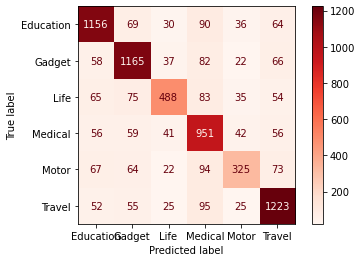

In [48]:
# Evaluate best Random Forest Model
model_score(best_rf_model, y_test, y_pred_best_rf, y_train, best_rf_model.predict(X_train))

### XGBoost Model
1. Handles nonlinear feature
2. Deals well with noise
3. Captures rule based patterns
4. Boosting makes it better at learning edge cases
5. Handles mixed categorical + numeric features very well

In [44]:
xgb_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("xgb", XGBClassifier(
            n_estimators=400,
            learning_rate=0.1,
            max_depth=8,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softmax',
            eval_metric='mlogloss',
            num_class=6,
            random_state=42))
            ])

#### _Train & Predict with XGBoost Model_
transform target to integer throu label encoder

In [53]:
# Encode y to integers
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [54]:
xgb_model.fit(X_train, y_train_encoded)
y_pred_xgb = xgb_model.predict(X_test)



MODEL REPORT
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1445
           1       0.76      0.82      0.79      1430
           2       0.71      0.62      0.66       800
           3       0.77      0.77      0.77      1205
           4       0.62      0.51      0.56       645
           5       0.78      0.84      0.81      1475

    accuracy                           0.76      7000
   macro avg       0.74      0.73      0.73      7000
weighted avg       0.76      0.76      0.76      7000


MODEL METRICS - TRAIN SET
Overall accuracy score 0.8422857142857143
Overall precision score 0.8420730042906527
Overall recall score 0.8422857142857143
Overall F1-score 0.8411731307444452
MODEL METRICS - TEST SET
Overall accuracy score 0.7588571428571429
Overall precision score 0.7555508986717056
Overall recall score 0.7588571428571429
Overall F1-score 0.7560509663186578

CONFUSION MATRIX


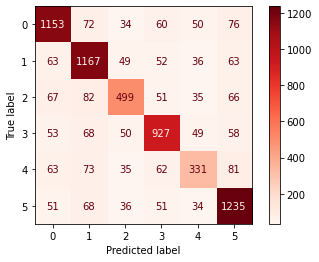

In [56]:
# Evaluate XGBoost Model
model_score(xgb_model, y_test_encoded, y_pred_xgb, y_train_encoded, xgb_model.predict(X_train))

### XGBoost Hyperparameter Tuning with GridSearch/CV

In [57]:
xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    n_classes=6,
    n_jobs=-1,
    random_state=42)

pipeline_xgb = Pipeline(
    steps = [
        ("preprocess", preprocessor),
        ("xgb", xgb)
    ])

param_grid_xgb = {
    'xgb__n_estimators' : [200,400],
    'xgb__max_depth' : [6,8, 10],
    'xgb__learning_rate' :[0.05, 0.1],
    'xgb__subsample' : [0.8, 1],
    'xgb__colsample_bytree' : [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train, y_train_encoded)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 144 out of 144 | elapsed: 19.5min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['income_band',
                                                                          'customer_segment',
                                                                          'occupation',
                                                                          'city',
                                                                          'kyc_risk_rating',
                                                                          'category',
                                                                          'channel'])])),
                             

#### _retrieve best model & best parameters_

In [58]:
print("Best Accuracy:", grid_search_xgb.best_score_)
print ("Best Parameters:", grid_search_xgb.best_params_)

best_xgb_model = grid_search_xgb.best_estimator_

y_pred_best_xgb = best_xgb_model.predict(X_test)

Best Accuracy: 0.7575358475909938
Best Parameters: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 6, 'xgb__n_estimators': 200, 'xgb__subsample': 0.8}



MODEL REPORT
              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1445
           1       0.76      0.82      0.79      1430
           2       0.71      0.63      0.67       800
           3       0.75      0.77      0.76      1205
           4       0.60      0.52      0.56       645
           5       0.80      0.83      0.82      1475

    accuracy                           0.76      7000
   macro avg       0.74      0.73      0.73      7000
weighted avg       0.76      0.76      0.76      7000


MODEL METRICS - TRAIN SET
Overall accuracy score 0.798
Overall precision score 0.7963314921096231
Overall recall score 0.798
Overall F1-score 0.7962763091516478
MODEL METRICS - TEST SET
Overall accuracy score 0.7595714285714286
Overall precision score 0.7568336052201117
Overall recall score 0.7595714285714286
Overall F1-score 0.7574801760973316

CONFUSION MATRIX


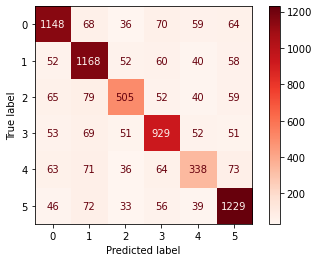

In [59]:
# Evaluate best XGBoost Model

model_score(best_xgb_model, y_test_encoded, y_pred_best_xgb, y_train_encoded, best_xgb_model.predict(X_train))

### Neural Network Model - Deep Learning

In [60]:
# works best with coded and scaled data
nn_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)   

#### _Transform the data - must convert to arrays for Keras_

In [61]:
X_train_nn = nn_preprocessor.fit_transform(X_train)
X_test_nn = nn_preprocessor.transform(X_test)

In [62]:
# Convert sparse to dense before training
X_train_dense = X_train_nn.toarray() if hasattr(X_train_nn, 'toarray') else X_train_nn
y_train_dense = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

In [63]:
# Encode string labels to integers
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_dense)
y_test_encoded = le.transform(y_test)

#### _Define the Neural Network Architecture_

In [64]:
input_dm = X_train_nn.shape[1]
num_classes = len(y_train.unique())

nn_model = Sequential([
    Dense(256, activation='relu', input_dim=input_dm),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])


nn_model.compile(optimizer='adam', 
                 loss='sparse_categorical_crossentropy', 
                 metrics=['accuracy'])


# Train the model

history = nn_model.fit(X_train_dense, y_train_encoded, 
                       epochs=15, 
                       batch_size=64, 
                       validation_split=0.2,
                       verbose=1)

# Evaluate the Neural Network Model

y_pred_nn_probs = nn_model.predict(X_test_nn)
y_pred_nn = np.argmax(y_pred_nn_probs, axis=1)

print('Neural Network Accuracy:', accuracy_score(y_test_encoded, y_pred_nn))

print('\n Classification Report:')
print(classification_report(y_test_encoded, y_pred_nn, target_names=le.classes_))

print('\n Confusion Matrix:')
print(confusion_matrix(y_test_encoded, y_pred_nn))


Epoch 1/15
350/350 [==============================] - 2s 5ms/step - loss: 1.0007 - accuracy: 0.7108 - val_loss: 0.8992 - val_accuracy: 0.7500
Epoch 2/15
350/350 [==============================] - 1s 4ms/step - loss: 0.8488 - accuracy: 0.7610 - val_loss: 0.8941 - val_accuracy: 0.7525
Epoch 3/15
350/350 [==============================] - 1s 4ms/step - loss: 0.8020 - accuracy: 0.7716 - val_loss: 0.9161 - val_accuracy: 0.7493
Epoch 4/15
350/350 [==============================] - 1s 3ms/step - loss: 0.7436 - accuracy: 0.7836 - val_loss: 0.9482 - val_accuracy: 0.7455
Epoch 5/15
350/350 [==============================] - 1s 4ms/step - loss: 0.6638 - accuracy: 0.7988 - val_loss: 1.0090 - val_accuracy: 0.7370
Epoch 6/15
350/350 [==============================] - 1s 3ms/step - loss: 0.5506 - accuracy: 0.8256 - val_loss: 1.1241 - val_accuracy: 0.7227
Epoch 7/15
350/350 [==============================] - 1s 3ms/step - loss: 0.4156 - accuracy: 0.8625 - val_loss: 1.3534 - val_accuracy: 0.7120
Epoch 

Neural Network Model doesn't perform very well as expected. reason could be the data generated is rule based

### Feature Importance using SHAP

In [65]:
def get_ct_feature_names(ct):
    """Extract feature names from ANY fitted ColumnTransformer"""
    feature_names = []
    
    for name, transformer, column_names in ct.transformers_:
        # Skip 'drop' or empty columns
        if name == 'drop' or (hasattr(column_names, '__len__') and len(column_names) == 0):
            continue
            
        # Handle passthrough columns
        if transformer == 'passthrough':
            feature_names.extend(column_names)
        # Handle transformers with feature names method
        elif hasattr(transformer, 'get_feature_names_out'):
            try:
                trans_names = transformer.get_feature_names_out()
                feature_names.extend([f"{name}__{x}" for x in trans_names])
            except:
                feature_names.extend([f"{name}__{x}" for x in column_names])
        else:
            # Fallback: original column names
            feature_names.extend([f"{name}__{x}" for x in column_names])
    
    return feature_names

# Use it
preprocessor = grid_search_xgb.best_estimator_.named_steps['preprocess']
feature_names = get_ct_feature_names(preprocessor)
print("Features:", len(feature_names))
print("Sample:", feature_names[:12])


Features: 11
Sample: ['cat__income_band', 'cat__customer_segment', 'cat__occupation', 'cat__city', 'cat__kyc_risk_rating', 'cat__category', 'cat__channel', 0, 1, 7, 10]


In [66]:
# prepare the preprocessed training data

X_train_transformed = grid_search_xgb.best_estimator_.named_steps['preprocess'].transform(X_train)

feature_names = grid_search_xgb.best_estimator_.named_steps['preprocess'].get_feature_names()
len(feature_names)



671

#### _Extract the trained XGBoost model_

In [67]:
xgb_model1 = grid_search_xgb.best_estimator_.named_steps['xgb']

#### _Create SHAP Explainer_ - SHapley Additive exPlanations

In [68]:
import shap

In [69]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)

XGBoost version: 2.1.4


In [70]:
# SHAP has special support for XGBoost using TreeExplainer

explainer = shap.TreeExplainer(xgb_model1)
shap_values = explainer.shap_values(X_train_transformed)

### Summary Plot (Global Feature Importance)
1. Shows most influential features from top to bottom
2. Direction of impact
3. Strength of impact(horizontal spread)

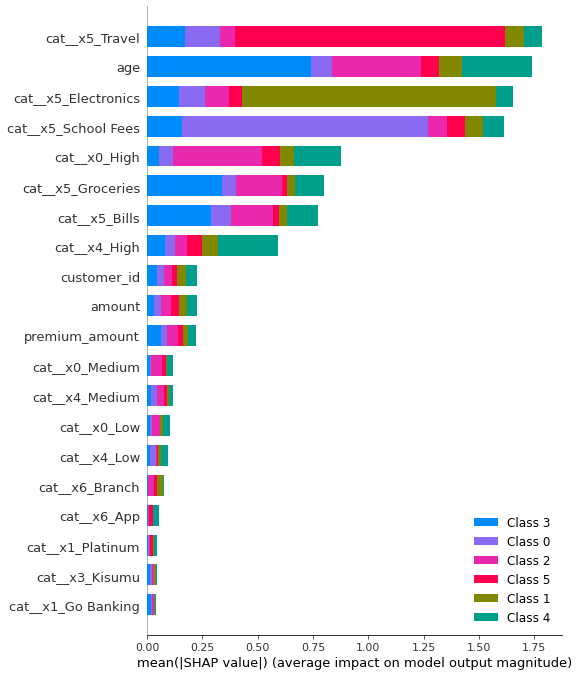

In [71]:
plt.figure(figsize=(12,6))
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)

#### _Bar Plot_

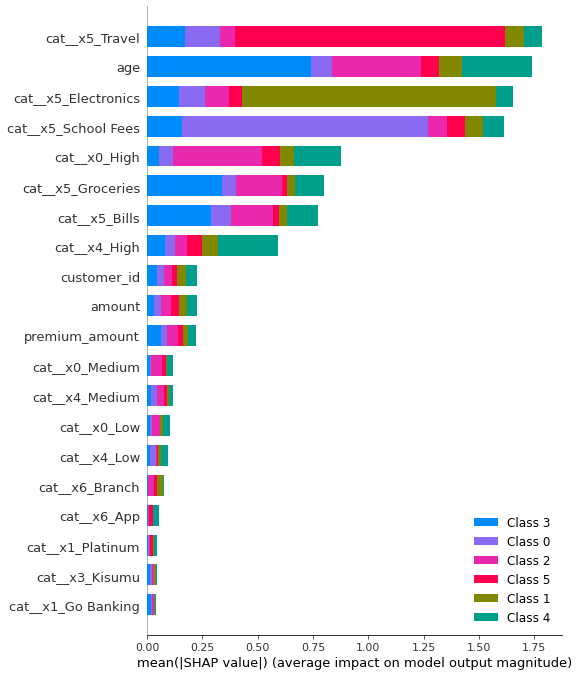

In [72]:
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names, plot_type='bar')